# Problem: Detecting an Exoplanet with MCMC (6 points)

Astronomers often detect exoplanets, planets orbiting other stars, by measuring tiny periodic changes in the star’s velocity. These "wobbles" can be modeled statistically as a noisy sinusoid. In this exercise, we’ll approach this problem using Bayesian inference, i.e., our goal is to infer the properties of an exoplanet given noisy data. You do not need to understand the physical meaning of the different parameters of the exoplanet model. The goal of this exercise is purely to understand how Bayesian inference can be used to fit complex models to measured data.

Assuming an exoplanet orbits a star, the radial velocity of the star is given by

$$v(t) = K \sin \left( \frac{2 \pi t}{T} + \phi \right) \, .$$

In the above equation $K > 0$, $t > 0$, and $0 \leq \phi \leq 2 \pi$ are free parameters of the model. ($K$, in turn, depends on the masses of the star and the planet.) In this exercise, we want to infer the posterior of these three quantities from the noisy data provided in `Problem_Set_2_Exoplanets.csv`. This file lists times $t$ and observed radial velocities $v_\mathrm{obs}$. The measured radial velocity equals the true velocity plus a Gaussian noise with a scatter of $\sigma_v = 1.3 \mathrm{m}/\mathrm{s}$. Thus, the total likelihood can be written as

$$\log \mathcal{L}(v_\mathrm{obs} | K, T, \phi) = - \frac{1}{2} \sum\limits_{i=1}^{n} \frac{(v(t_i) - v_{\mathrm{obs}, i})^2}{\sigma_v^2} \, ,$$

where the sum goes over all measurements and their respective times.

(a) Use your MCMC code developed in class to infer posterior distributions for the three parameters. Please assume uniform priors in the ranges $[0, 2 \mathrm{m} / \mathrm{s}]$ for $K$, $[0, 2 \mathrm{years}]$ for $T$ and $[0, 2 \pi]$ for $\phi$. Show trace plots for all three parameters to demonstrate that your results are converged. Run the MCMC for at least $10,000$ steps and discard at least $2,000$ as burn-in.

(b) Visualize the posterior distribution. Specifically, produce three one-dimensional histograms of the individual parameters and three two-dimensional histograms of all possible choices of two parameters, i.e., $K$ vs. $T$, $K$ vs. $\phi$, and $T$ vs. $\phi$.

(c) Repeat exercise (b) using a kernel density estimate (KDE) of your derived posterior instead of the sampled posterior directly. Determine the kernel bandwidth for the KDE using whatever method you think is appropriate but please justify your choice.

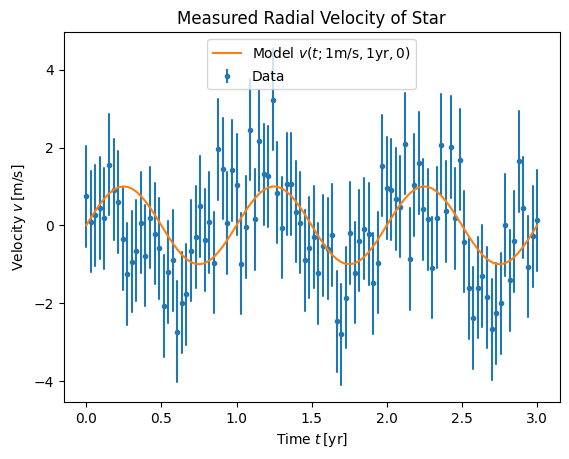

In [10]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def velocity(t, K, T, phi):
    return K * np.sin(2 * np.pi * t / T + phi)


df = pd.read_csv('Problem_Set_2_Exoplanets.csv')
plotline, caps, barlinecols = plt.errorbar(df['t'], df['v'], yerr=1.3, fmt='o', ms=3, zorder=0, label='Data')
plt.setp(barlinecols[0], capstyle="round")
K, T, phi = 1, 1, 0
plt.plot(df['t'], velocity(df['t'], K, T, phi), label=rf'Model $v(t; 1 $m/s$, 1 $yr$, 0)$')
plt.xlabel(r'Time $t \, [\mathrm{yr}]$')
plt.ylabel(r'Velocity $v \, [\mathrm{m} / \mathrm{s}]$')
plt.title("Measured Radial Velocity of Star")
plt.legend(loc='upper center');

## MCMC Supplementary Code

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def log_prior(x):
    """Compute the logarithm of the prior.

    The prior is a flat prior in the range [-10, +10] for all parameters.

    Parameters
    ----------
    x : numpy.ndarray of shape (n_points, n_dim) or (n_dim, )
        Point(s) in parameter space.

    Returns
    -------
    float or numpy.ndarray
        Natural logarithm of the prior for the input parameter(s).

    """
    return np.where(np.any(np.abs(x) > 10, axis=-1), -np.inf, 0)

def log_likelihood(x):
    """Compute the logarithm of the likelihood.

    Parameters
    ----------
    x : numpy.ndarray of shape (n_points, 2) or (2, )
        Point(s) in parameter space.

    Returns
    -------
    float or numpy.ndarray
        Natural logarithm of the likelihood for the input parameter(s).

    """
    return -((1 - x[..., 0])**2 + (x[..., 1] - x[..., 0]**2)**2)

def log_posterior(x):
    """Compute the logarithm of the posterior.

    Parameters
    ----------
    x : numpy.ndarray of shape (n_points, 2) or (2, )
        Point(s) in parameter space.

    Returns
    -------
    float or numpy.ndarray
        Natural logarithm of the posterior for the input parameter(s).

    """
    return log_prior(x) + log_likelihood(x)

def run_mcmc(start, posterior, n_iter, scale=1.0, burn_in=0):
    """Run an MCMC chain.

    Attributes
    ----------
    start : numpy.ndarray of shape (n_dim, )
        Starting position.
    posterior : callable
        Function that returns the logarithm of the posterior.
    n_iter : int
        Number of iterations.
    scale : float, optional
        Proposal scale. Default is 1.
    burn_in : int, optional
        Number of samples to remove as burn-in.

    Returns
    -------
    chain : numpy.ndarray of shape (n_samples, n_dim)
            Posterior chain.
    f_accept : float
            Acceptance fraction.
    """
    x = start.copy()
    log_p = posterior(x)
    chain = np.zeros((n_iter + 1, len(x)))
    chain[0] = x

    for i in range(1, n_iter + 1):

        # Draw a random step
        step = np.random.normal(scale=scale, size=len(x))

        # Calculate the new proposed position.
        x_new = x + step

        # Your code to decide whether to accept x_new goes here.
        p_x = np.exp(log_posterior(x))
        p_x_prime = np.exp(log_posterior(x_new))
        acceptance_prob = p_x_prime / p_x
        acceptance_prob = min(acceptance_prob, 1)

        if np.random.uniform(0, 1) < acceptance_prob:
            x = x_new

        # Add the current position to the chain.
        chain[i] = x

    return chain, np.mean(chain[1:] != chain[:-1])

## Infer Posterior Distributions

/var/folders/7v/j86gnt7s2sn8c409_1cq9mrr0000gn/T/ipykernel_51342/337397570.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


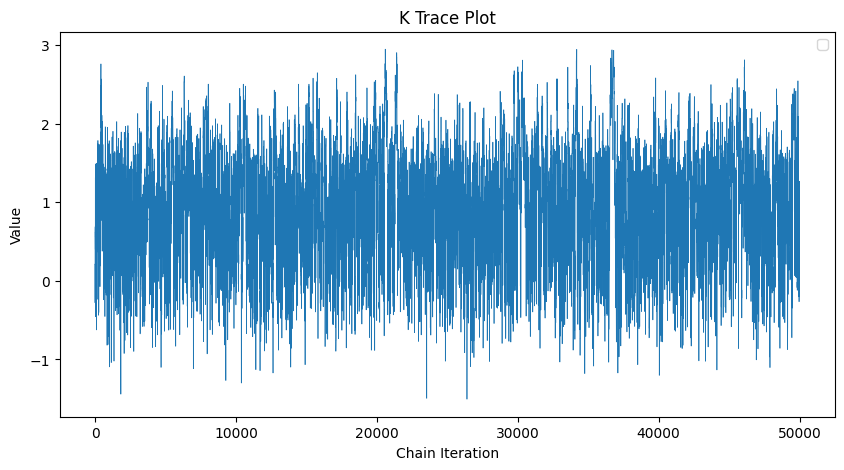

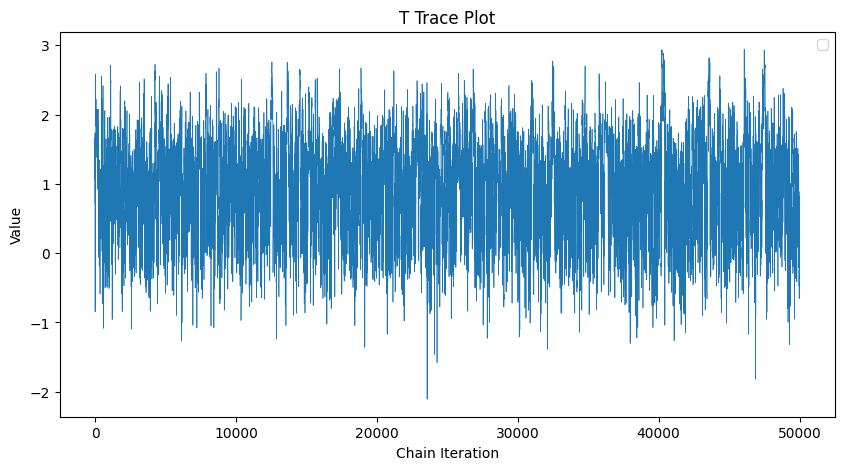

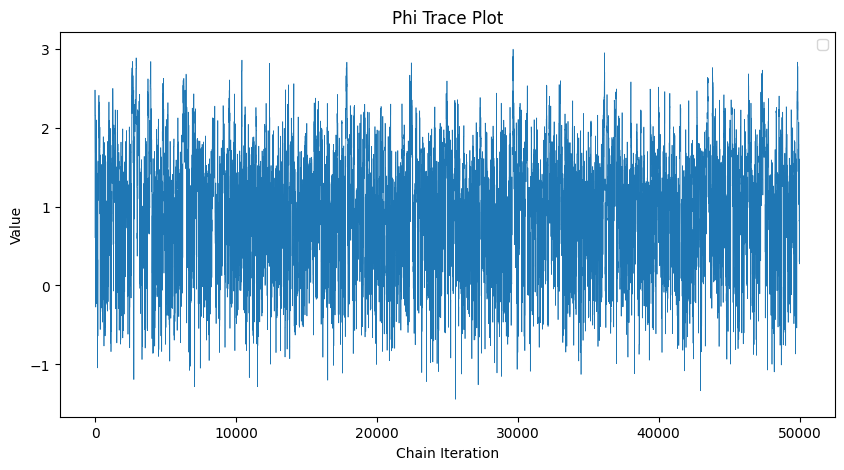

In [26]:
k_uniform = np.random.uniform(0, 2, 3)
t_uniform = np.random.uniform(0, 2, 3)
phi_uniform = np.random.uniform(0, 2 * math.pi, 3)

def make_plot(title, sequence):
    burn_in = 3000
    num_steps = 50000

    fig, ax = plt.subplots(figsize=(10, 5))
    chain, f_accept = run_mcmc(sequence, log_posterior, num_steps, burn_in = burn_in)
    plt.plot(chain[:, 0], linewidth = 0.5)
    plt.xlabel("Chain Iteration")
    plt.ylabel("Value")
    plt.title(f"{title} Trace Plot")
    plt.legend()
    plt.show()

make_plot("K", k_uniform)
make_plot("T", t_uniform)
make_plot("Phi", phi_uniform)


## Visualize Posterior

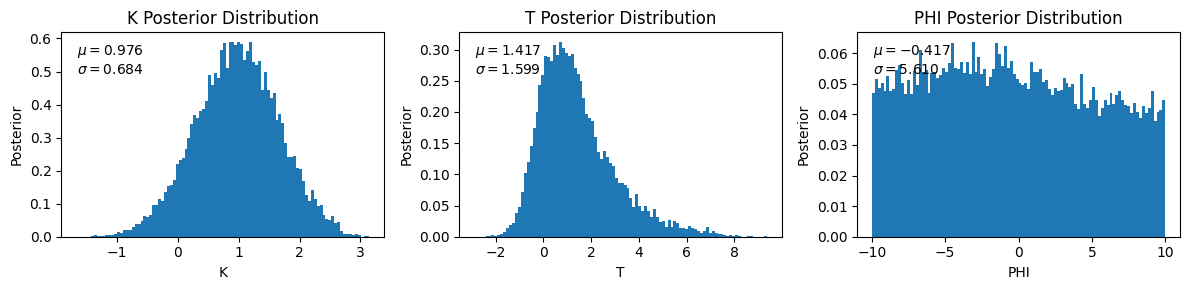

In [25]:
fig, axs = plt.subplots(ncols=3, figsize=(12, 3))
chain = run_mcmc(np.zeros(3), log_posterior, 100000)[0]
vars = ["K", "T", "PHI"]

for i, (ax, data) in enumerate(zip(axs, chain.T)):
    ax.hist(data, bins=100, density=True)
    ax.set_xlabel(vars[i])
    ax.set_ylabel(r'Posterior')
    ax.text(0.05, 0.95, rf'$\mu = {np.mean(data):.3f}$', transform=ax.transAxes, horizontalalignment='left', verticalalignment='top')
    ax.text(0.05, 0.85, rf'$\sigma = {np.std(data):.3f}$', transform=ax.transAxes, horizontalalignment='left', verticalalignment='top')
    ax.title.set_text(f"{vars[i]} Posterior Distribution")
plt.tight_layout()
plt.show()

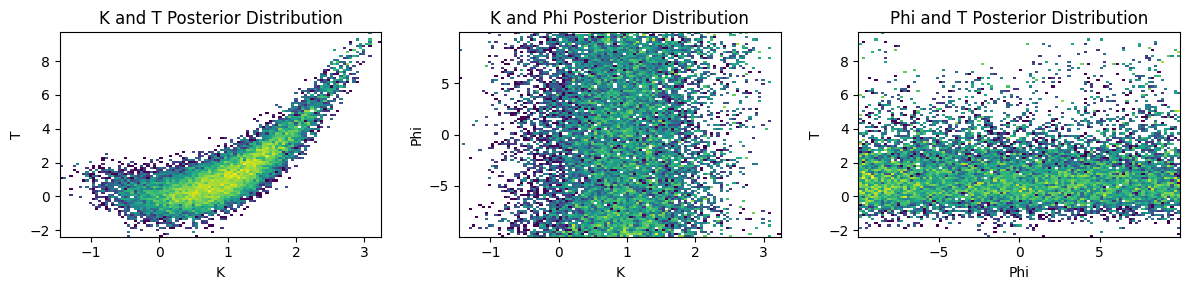

In [21]:
from matplotlib.colors import LogNorm

fig, axs = plt.subplots(ncols=3, figsize=(12, 3))
chain = run_mcmc(np.zeros(3), log_posterior, 50000, burn_in=3000)[0]
k_dist, t_dist, phi_dist = chain.T

ax_index = 0

def make_plot(sequence1, label1, sequence2, label2):
    global ax_index
    ax = axs[ax_index]
    ax.hist2d(sequence1, sequence2, bins=(100, 100), density=True, norm=LogNorm())
    ax.set_xlabel(f"{label1}")
    ax.set_ylabel(f"{label2}")
    ax.title.set_text(f"{label1} and {label2} Posterior Distribution")
    ax_index += 1

make_plot(k_dist, "K", t_dist, "T")
make_plot(k_dist, "K", phi_dist, "Phi")
make_plot(phi_dist, "Phi", t_dist, "T")
plt.tight_layout()
plt.show()

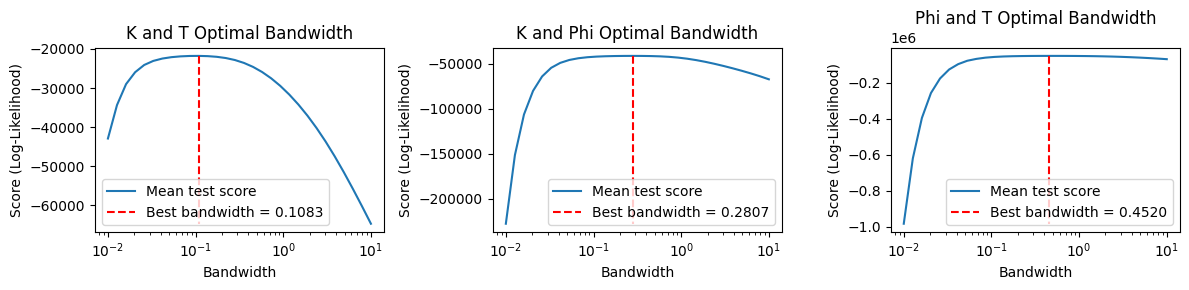

In [28]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

fig, axs = plt.subplots(ncols=3, figsize=(12, 3))

k_t = pd.DataFrame({"K": k_dist, "T": t_dist})
k_phi = pd.DataFrame({"K": k_dist, "Phi": phi_dist})
phi_t = pd.DataFrame({"Phi": phi_dist, "T": t_dist})

ax_index = 0

def select_bandwidth(X):
    global ax_index

    cv = GridSearchCV(KernelDensity(rtol=1e-2), param_grid=dict(bandwidth=np.logspace(-2, 1, 30)),n_jobs=-1).fit(X)
    results = pd.DataFrame({'param_bandwidth': cv.cv_results_['param_bandwidth'], 'mean_test_score': cv.cv_results_['mean_test_score']})
    results_sorted = results.sort_values(by='mean_test_score', kind = "quicksort", ascending = False)

    axs[ax_index].plot(cv.cv_results_['param_bandwidth'], cv.cv_results_['mean_test_score'], label = "Mean test score")
    axs[ax_index].vlines(results_sorted["param_bandwidth"].iloc[0], results_sorted["mean_test_score"].iloc[0], results_sorted["mean_test_score"].iloc[-1], linestyle = 'dashed', color = 'red', label = f"Best bandwidth = {results_sorted["param_bandwidth"].iloc[0]:,.4f}")
    axs[ax_index].set_xscale('log')
    axs[ax_index].set_xlabel('Bandwidth')
    axs[ax_index].set_ylabel('Score (Log-Likelihood)')
    label1, label2 = X.keys()
    axs[ax_index].title.set_text(f'{label1} and {label2} Optimal Bandwidth')
    axs[ax_index].legend(loc='best')
    ax_index += 1

    #display(results_sorted)
    return np.round(results_sorted["param_bandwidth"].iloc[0], decimals=4)

k_t_bandwidth = select_bandwidth(k_t)
k_phi_bandwidth = select_bandwidth(k_phi)
phi_t_bandwidth = select_bandwidth(phi_t)

plt.tight_layout()
plt.show()

I decided to use mean likelihood to determine best bandwidth because, though it is a bit of an estimation, it is concise and rather accurate. Visualizing the mean score in plots allows for more accurate narrowing of the ranges.

/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(


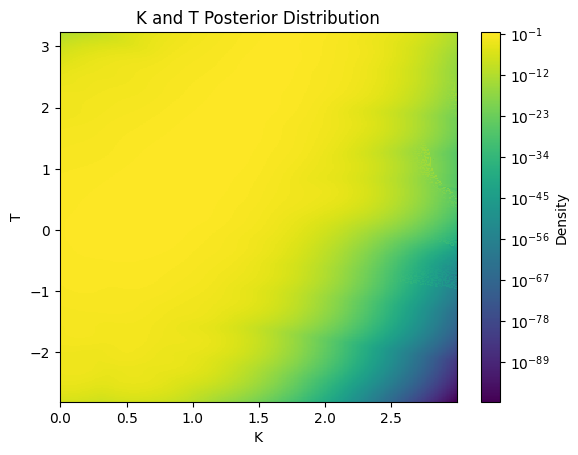

/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(


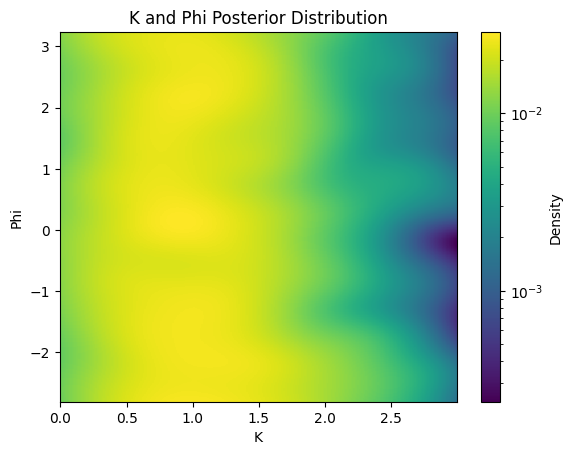

/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(


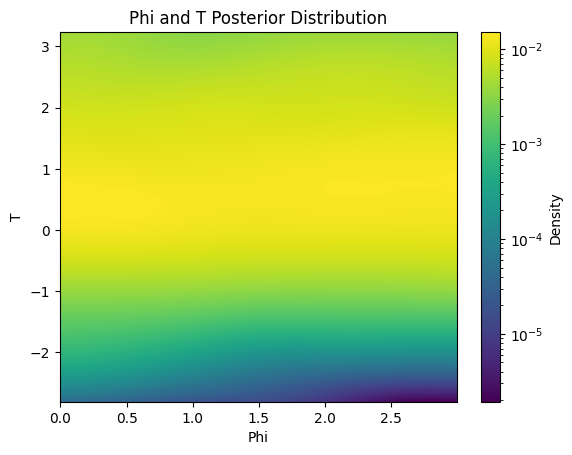

In [29]:
from matplotlib.colors import LogNorm

def make_plot(X, bandwidth):
    kde = KernelDensity(bandwidth=bandwidth, rtol=1e-4).fit(X)
    xmin, xmax = (min(df.iloc[:, 0]), max(df.iloc[:, 0]))
    ymin, ymax = (min(df.iloc[:, 1]), max(df.iloc[:, 1]))
    label1, label2 = X.keys()
    x, y = np.mgrid[xmin:xmax:.01, ymin:ymax:.01]
    X = np.column_stack((x.ravel(), y.ravel()))
    plt.pcolormesh(x, y, np.exp(kde.score_samples(X).reshape(x.shape)), norm = LogNorm())
    plt.title(f"{label1} and {label2} Posterior Distribution")
    plt.xlabel(f"{label1}")
    plt.ylabel(f"{label2}")
    plt.colorbar(label='Density')
    plt.show()

make_plot(k_t, k_t_bandwidth)
make_plot(k_phi, k_phi_bandwidth)
make_plot(phi_t, phi_t_bandwidth)